In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("../data/raw/customers.csv")

transactions = pd.read_csv("../data/raw/transactions.csv")

customers.head()

,customer_id,customer_name,age,gender,state,customer_segment,join_date,annual_income
0,1,Customer 1,28,Male,Florida,Mass Affluent,2024-08-02,79106.36
1,2,Customer 2,27,Other,North Carolina,High Value,2025-02-17,159908.35
2,3,Customer 3,22,Male,New York,Mass Affluent,2021-03-07,141178.16
3,4,Customer 4,56,Male,North Carolina,Entry,2021-02-24,78496.94
4,5,Customer 5,38,Male,California,Entry,2024-04-21,104855.11


In [3]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [4]:
# Build customer-level dataset in Pandas
completed_transactions = transactions[
    transactions["status"] == "Completed"
]

customer_summary = (
    completed_transactions
    .groupby("customer_id")
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),
        total_amount=(
            "amount",
            "sum"
        ),
        average_transaction_value=(
            "amount",
            "mean"
        ),
        first_transaction_date=(
            "transaction_date",
            "min"
        ),
        last_transaction_date=(
            "transaction_date",
            "max"
        )
    )
    .reset_index()
)

# Merge customer attributes

customer_summary = customer_summary.merge(
    customers,
    on="customer_id",
    how="right"
)

customer_summary.head()

,customer_id,total_transactions,total_amount,average_transaction_value,first_transaction_date,last_transaction_date,customer_name,age,gender,state,customer_segment,join_date,annual_income
0,1,7.0,568.26,81.180000,2024-01-16,2025-11-09,Customer 1,28,Male,Florida,Mass Affluent,2024-08-02,79106.36
1,2,7.0,473.98,67.711429,2024-01-06,2025-10-24,Customer 2,27,Other,North Carolina,High Value,2025-02-17,159908.35
2,3,NaN,NaN,NaN,NaT,NaT,Customer 3,22,Male,New York,Mass Affluent,2021-03-07,141178.16
3,4,12.0,949.09,79.090833,2024-01-31,2025-12-15,Customer 4,56,Male,North Carolina,Entry,2021-02-24,78496.94
4,5,32.0,3229.89,100.934062,2024-01-31,2025-12-31,Customer 5,38,Male,California,Entry,2024-04-21,104855.11


In [5]:
customer_summary.shape

(5000, 13)

In [6]:
# Create activity segments in Python
def classify_activity(transactions):
    if pd.isna(transactions) or transactions == 0:
        return "Inactive"
    elif transactions <= 5:
        return "Low Activity"
    elif transactions <= 15:
        return "Medium Activity"
    else:
        return "High Activity"

customer_summary["activity_segment"] = (
    customer_summary["total_transactions"]
    .apply(classify_activity)
)

customer_summary[
    "activity_segment"
].value_counts()

activity_segment
High Activity      1860
Medium Activity    1848
Inactive           1099
Low Activity        193
Name: count, dtype: int64

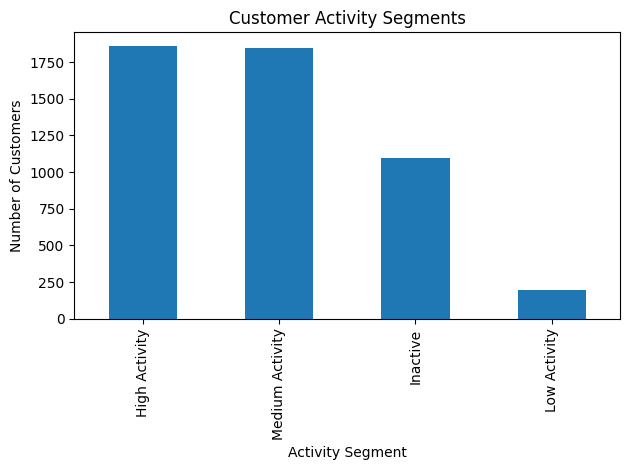

In [7]:
# Visualize customer segments

segment_counts = (
    customer_summary[
        "activity_segment"
    ]
    .value_counts()
)

segment_counts.plot(
    kind="bar",
    title="Customer Activity Segments"
)

plt.xlabel("Activity Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [8]:
# Analyze segment revenue
segment_revenue = (
    customer_summary
    .groupby("activity_segment")
    ["total_amount"]
    .sum()
    .sort_values(
        ascending=False
    )
)

segment_revenue

activity_segment
High Activity      17150541.28
Medium Activity     6929874.70
Low Activity         388356.95
Inactive                  0.00
Name: total_amount, dtype: float64

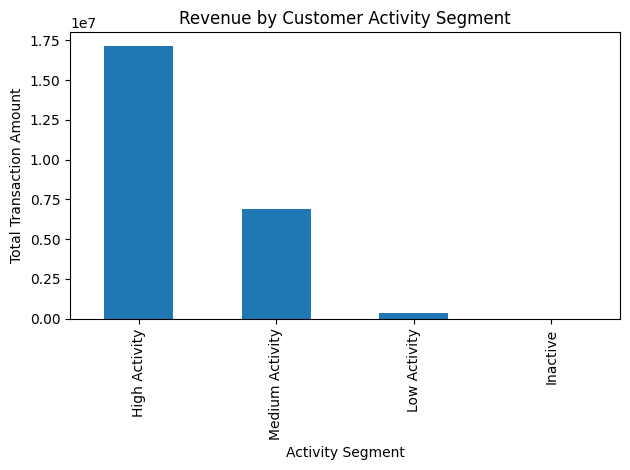

In [9]:
segment_revenue.plot(
    kind="bar",
    title="Revenue by Customer Activity Segment"
)

plt.xlabel("Activity Segment")
plt.ylabel("Total Transaction Amount")
plt.tight_layout()
plt.show()

In [10]:
# Analyze income and customer activity
customer_summary.groupby(
    "activity_segment"
).agg(
    customers=("customer_id", "count"),
    average_income=("annual_income", "mean"),
    average_transactions=(
        "total_transactions",
        "mean"
    ),
    average_transaction_amount=(
        "total_amount",
        "mean"
    )
).round(2)


,customers,average_income,average_transactions,average_transaction_amount
activity_segment,,,,
High Activity,1860,139473.08,25.31,9220.72
Inactive,1099,141876.66,NaN,NaN
Low Activity,193,139360.91,4.28,2012.21
Medium Activity,1848,136114.22,10.16,3749.93
